 
# <font color='#F5B167'> MD009 Simulación vida útil de un satélite </font>

Se desea calcular la esperanza de la vida útil de un satélite, cuyo equipamiento principal (sujeto a fallos) consiste en dos ordenadores y un equipamiento de transmisión. 

El satélite funciona mientras al menos uno de los dos ordenadores y el equipo de transmisión funcionen. En el
momento del lanzamiento, los ordenadores poseen una vida útil aleatoria siguiendo una distribución de Weibull con parámetro de forma 1.5 y parámetro de escala 500 (días); y el equipamiento de transmisión posee una vida útil aleatoria de distribución Weibull con parámetro de forma 2 y parámetro de escala 1500 (días).

Para la estimación de la esperanza de vida útil y de la desviación, podemos usar un método MC, generando 10000 experimentos.

Primero, podemos dibujar cómo son las distribuciones de Weibull referidas.

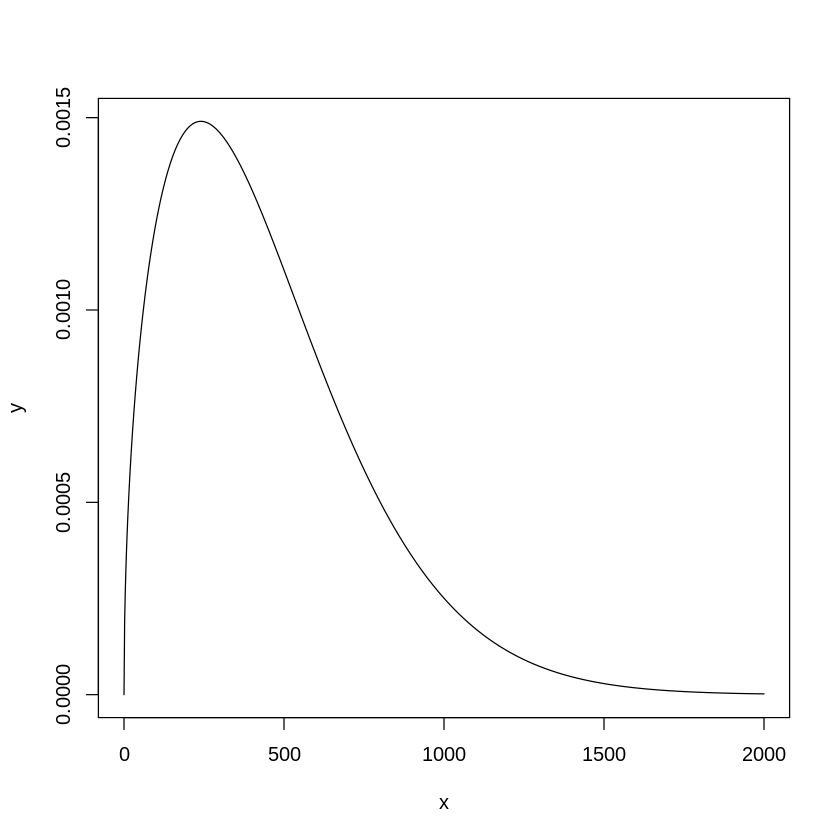

In [1]:
#ordenadores
x <- seq(0, 2000, length = 1000)
y <- dweibull(x, shape = 1.5, scale = 500)
plot(x, y, type = "l", lwd = 1)

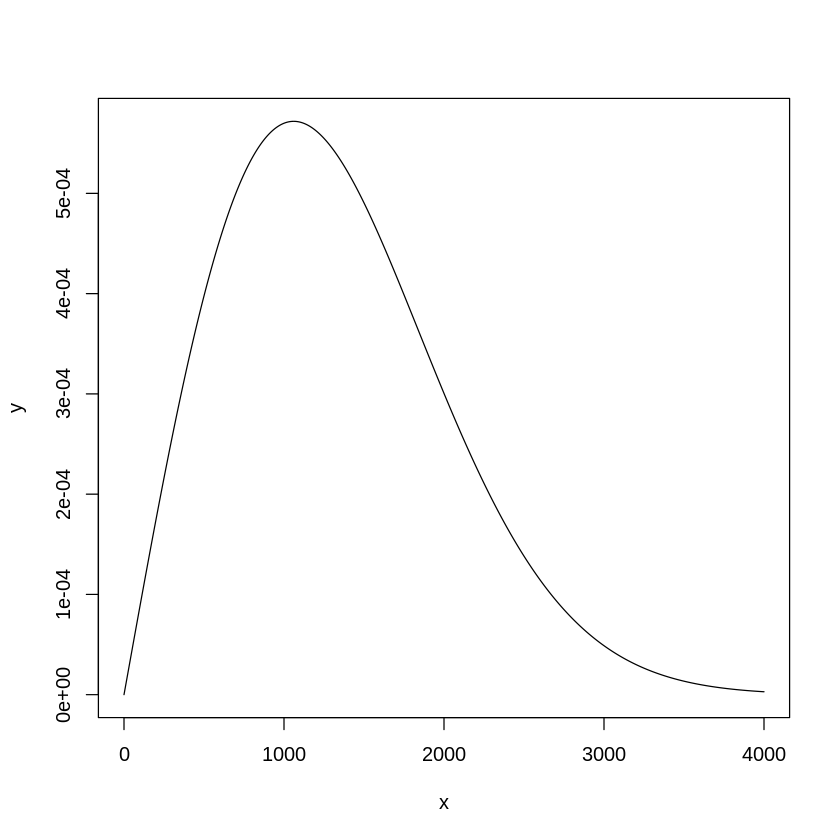

In [2]:
#equipo de transmisión
x <- seq(0, 4000, length = 1000)
y <- dweibull(x, shape = 2, scale = 1500)
plot(x, y, type = "l", lwd = 1)

Simulación MC del tiempo de vida del satélite:

In [3]:
vida = 0
vida2 = 0
rms = 0
tfallo <- 0
N = 10000
for(k in 1:N){
    tFalloOrdenador1 = rweibull(1, shape = 1.5, scale = 500)
    tFalloOrdenador2 = rweibull(1, shape = 1.5, scale = 500)
    tFalloTransmision = rweibull(1, shape = 2, scale = 1500)
    if(tFalloOrdenador1 < tFalloOrdenador2){
        tFalloO = tFalloOrdenador2
    }else{
        tFalloO = tFalloOrdenador1
    }
    if(tFalloO < tFalloTransmision){
        tFalloSatelite = tFalloO
    }else{
        tFalloSatelite = tFalloTransmision
    }
    tfallo[k] = tFalloSatelite
    vida = vida + tFalloSatelite
    vida2 = vida2 + tFalloSatelite * tFalloSatelite
}
vida = vida/N
rms = sqrt((vida2/N-vida*vida)/(N-1))
print(vida)
print(rms)

[1] 562.6312
[1] 2.789982


Según esta simulación el tiempo de vida útil del satélite promedio sería de $565.7\pm2.8$ días.

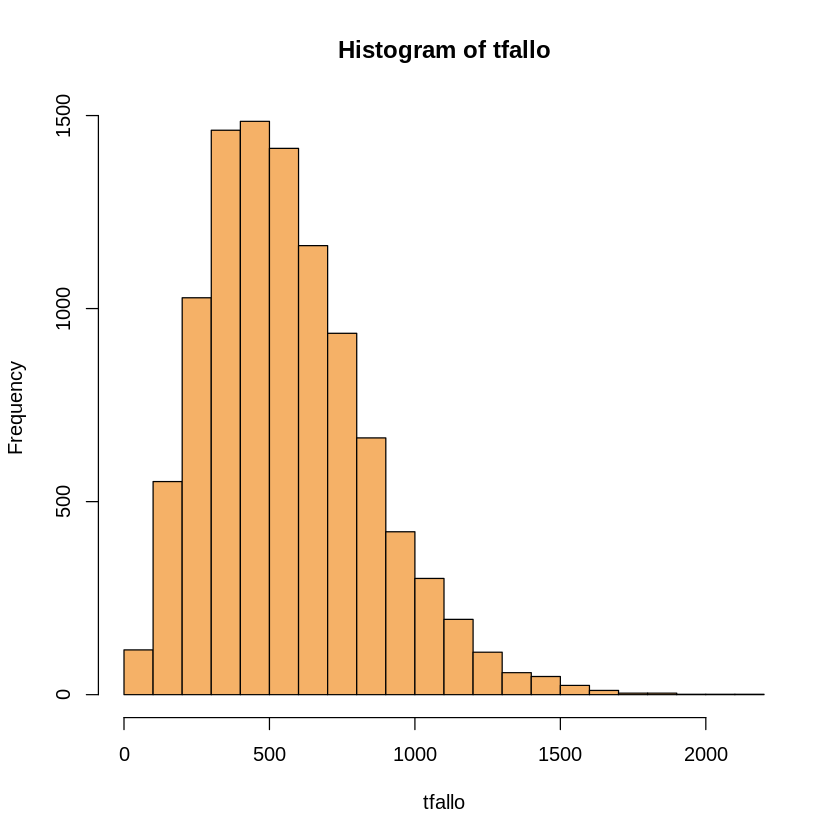

In [4]:
hist(tfallo, col='#F5B167')

De hecho, podríamos intentar modelizar el resultado obtenido ajustando una distribución de Weibull.

Loading required package: fitdistrplus

Loading required package: survival



Fitting of the distribution ' weibull ' by maximum likelihood 
Parameters : 
        estimate Std. Error
shape   2.130936 0.01617855
scale 636.191821 3.15143618
Loglikelihood:  -69933.29   AIC:  139870.6   BIC:  139885 
Correlation matrix:
          shape     scale
shape 1.0000000 0.3202402
scale 0.3202402 1.0000000


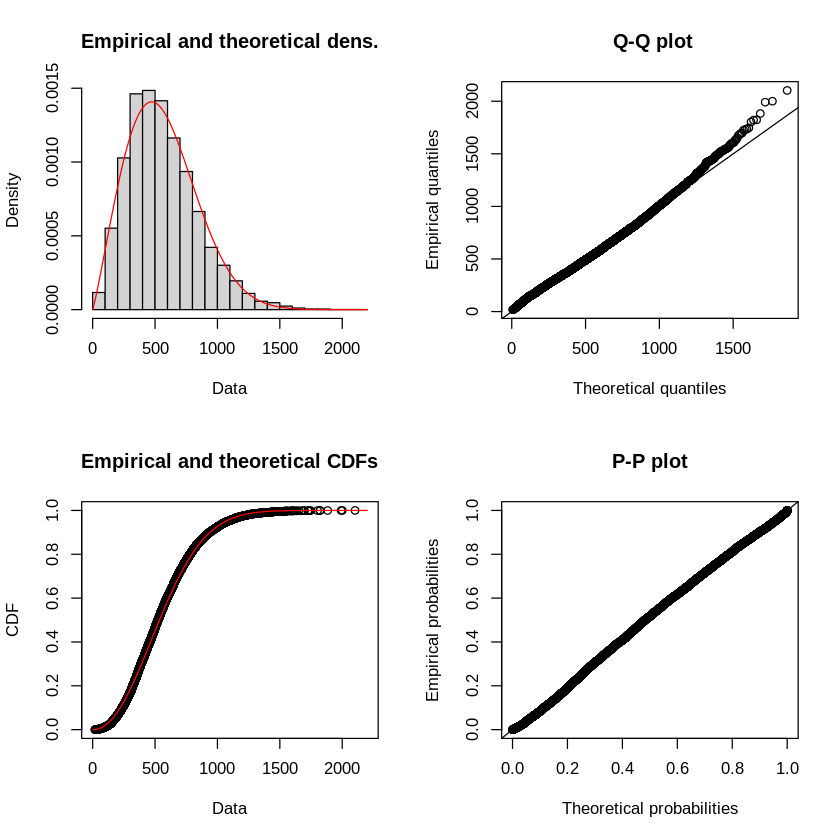

In [5]:
library(MASS)
require(fitdistrplus)
fit1 <- fitdist(tfallo, "weibull") #maximum likelihood
summary(fit1)
plot(fit1)

Obtenemos un parámetro de forma de $2.143 \pm 0.016$ y un parámetro de escala de $639.8\pm 3.2$.